# Behavioural drivers of annual revenue — NovaRetail+

NovaRetail+ is a Latin American ecommerce platform with millions of users. Closing out 2024, the Growth and Retention team put one question on the table: **which customer behaviours are most strongly associated with the annual revenue a customer generates?**

The honest answer turns out to be more interesting than the obvious one. The strongest correlation in this dataset is a trap, the second strongest is weaker than it looks, and the most valuable thing I found was not a correlation at all — it was a segment hiding inside the target variable.

Everything below is correlational. I state that up front because the headline number here is easy to mistake for a lever the business can pull, and it is not one.

## 1. What the data contains

Fifteen thousand customers, twelve columns. Before correlating anything I check what loads, what type each column is, and whether any missing values are sitting there ready to distort a coefficient.

In [1]:
# Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pointbiserialr, chi2_contingency

In [2]:
# The dataset is not versioned in this repository; place it under data/ to re-run
customer_behaviour = pd.read_csv('data/novaretail_comportamiento_clientes_2024.csv')

customer_behaviour.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  str    
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  str    
 10  region                     15000 non-null  str    
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), str(3)
memory usage: 1.4 MB


In [3]:
# First rows, to see the shape of the data
customer_behaviour.head()

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


### Data dictionary

| Column | Meaning |
|---|---|
| `id_cliente` | Unique customer identifier |
| `edad` | Customer age |
| `nivel_ingreso` | Customer's own estimated annual income |
| `visitas_mes` | Visits to the app or site during the month |
| `compras_mes` | Purchases made during the month |
| `gasto_publicidad_dirigida` | Ad spend allocated to that user |
| `satisfaccion` | Satisfaction score, 1 to 5 |
| `miembro_premium` | 1 if the customer holds a premium subscription, 0 otherwise |
| `abandono` | 1 if the customer churned, 0 otherwise |
| `tipo_dispositivo` | Device used: móvil, escritorio or tablet |
| `region` | Region: norte, sur, oeste or este |
| `ingreso_anual` | **Annual revenue the customer generates for the company** |

`ingreso_anual` is the target of the whole analysis. Note that `nivel_ingreso` and `ingreso_anual` sound alike but measure opposite sides of the relationship: what the customer earns, and what the company earns from them.

> Column names stay in Spanish because they come from the source file.

## 2. Variable types decide the method

This is not a formality. The coefficient I can use for each pair depends entirely on what type each variable is, so sorting the columns into numeric, binary and categorical *is* the analysis plan.

One type needs fixing first: `edad` arrives as float, though age here never carries decimals.

In [4]:
# Age is stored as float but holds no decimals; integer is the honest type
customer_behaviour['edad'] = customer_behaviour['edad'].astype(int)
customer_behaviour.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  str    
 1   edad                       15000 non-null  int64  
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  str    
 10  region                     15000 non-null  str    
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(4), int64(5), str(3)
memory usage: 1.4 MB


### The numeric variables

`edad`, `nivel_ingreso`, `visitas_mes`, `compras_mes`, `gasto_publicidad_dirigida`, `satisfaccion` and `ingreso_anual`.

I pull `miembro_premium` and `abandono` out of this group. Pandas reads them as integers, but they are flags — their mean would be a proportion, not an average, and treating them as numeric would put meaningless rows in the descriptive table.

In [5]:
# Descriptive statistics, excluding the two binary flags
numeric_vars = (customer_behaviour
                       .select_dtypes(include='number')
                       .drop(columns=['miembro_premium', 'abandono']))
numeric_vars.describe()

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,244.690000


**What the distributions show**

- `edad` — mean 38.3 against median 38.0: symmetric, no long tail.
- `nivel_ingreso` — mean and median both near 30,000, CV ≈ 33%: symmetric with moderate spread.
- `visitas_mes` — mean 10.0 against median 10.0: symmetric.
- `compras_mes` — most customers buy once a month, with a tail reaching 8. Standard deviation almost equals the mean (CV ≈ 92%), so the spread is as large as the central value.
- `gasto_publicidad_dirigida` — moderate dispersion, CV ≈ 54%.
- `satisfaccion` — bounded 1 to 5, centred at 3.6.
- `ingreso_anual` — **the 25th percentile is 0**, so at least a quarter of customers generated no revenue at all. That is a whole segment hiding inside the target variable, and I come back to it in Section 5.

### The binary flags

In [6]:
# Confirm each flag really holds only two values
customer_behaviour[['miembro_premium', 'abandono']].nunique()

miembro_premium    2
abandono           2
dtype: int64

Both hold exactly two values, coded 0 and 1. No unexpected categories, no cleaning needed.

### The categorical columns

In [7]:
# Naming the columns beats inferring them by dtype: it is explicit about what
# counts as a category here, and it does not depend on how pandas maps string types
categorical_vars = customer_behaviour[['id_cliente', 'tipo_dispositivo', 'region']]
print(categorical_vars.nunique())

id_cliente          15000
tipo_dispositivo        3
region                  4
dtype: int64


In [8]:
# How the two real categoricals are distributed
print(customer_behaviour['tipo_dispositivo'].value_counts(normalize=True).round(4))
print()
print(customer_behaviour['region'].value_counts())

tipo_dispositivo
móvil         0.6545
escritorio    0.2480
tablet        0.0975
Name: proportion, dtype: float64

region
norte    4395
oeste    3810
sur      3726
este     3069
Name: count, dtype: int64


`id_cliente` has 15,000 unique values on 15,000 rows — one per customer, so it is an identifier rather than a category, and it carries no analytical information.

- `tipo_dispositivo` — móvil dominates at 65.5%, escritorio 24.8%, tablet 9.7%.
- `region` — norte leads with 4,395 customers and este trails with 3,069. No region is small enough to make its subgroup unreliable.

### What I am assuming

- The analysis uses the full dataset. No sampling, so no sampling error to account for.
- The data carries no recording errors and is correctly typed once `edad` is fixed.
- The coefficient is chosen by variable type, never by which one returns a larger number:

| Pairing | Coefficient | Why |
|---|---|---|
| Numeric × numeric | Pearson | Measures linear relationship |
| Numeric × numeric | Spearman | Measures monotonic relationship, no normality assumed |
| Numeric × binary | Point-biserial | Designed for a continuous variable against a 0/1 flag |
| Categorical × categorical | Cramér's V | Rescales chi-square to a comparable 0–1 range |

I report Pearson and Spearman together throughout. When the two agree, the relationship holds whether measured by magnitude or by rank order — if they diverge, outliers or curvature are doing the work.

**The assumption underneath all of it:** this maps relationships between variables. It does not establish that one causes another.

## 3. Where the relationships are

I look at the shape before putting numbers on it. A coefficient collapses fifteen thousand points into one digit, and that digit hides outliers, curvature and clusters — all of which change what the number means.

### The correlation matrix

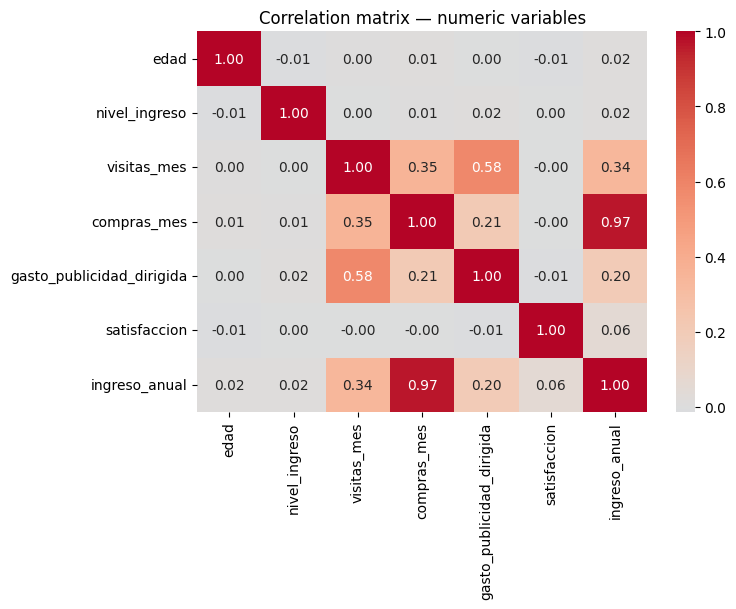

In [9]:
corr_matrix = numeric_vars.corr()

plt.figure(figsize=(7.8, 6.2))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation matrix — numeric variables')
plt.tight_layout()
plt.show()

**What the matrix shows**

- `compras_mes` and `ingreso_anual` sit at **0.97** — the strongest value in the matrix by a wide margin, and far past the 0.85 threshold at which two variables stop carrying independent information.
- `ingreso_anual` against `visitas_mes` is **0.34**: moderate, and the only other relationship with the target worth examining.
- `gasto_publicidad_dirigida` and `visitas_mes` reach **0.58**, but neither of them is the target variable; this is a relationship between two inputs.
- `edad`, `nivel_ingreso` and `satisfaccion` sit near zero against everything, including revenue. Nothing about who the customer is predicts what they spend — only what they do.

### Why I am not plotting everything

A full pairplot would draw twenty-one panels, and the matrix above already shows most of those pairs sitting near zero. Plotting them would add visual noise without adding information, so I go straight to the two pairs that involve the target.

### The two pairs that matter

Both are plotted against `ingreso_anual`, since that is the variable the question is about.

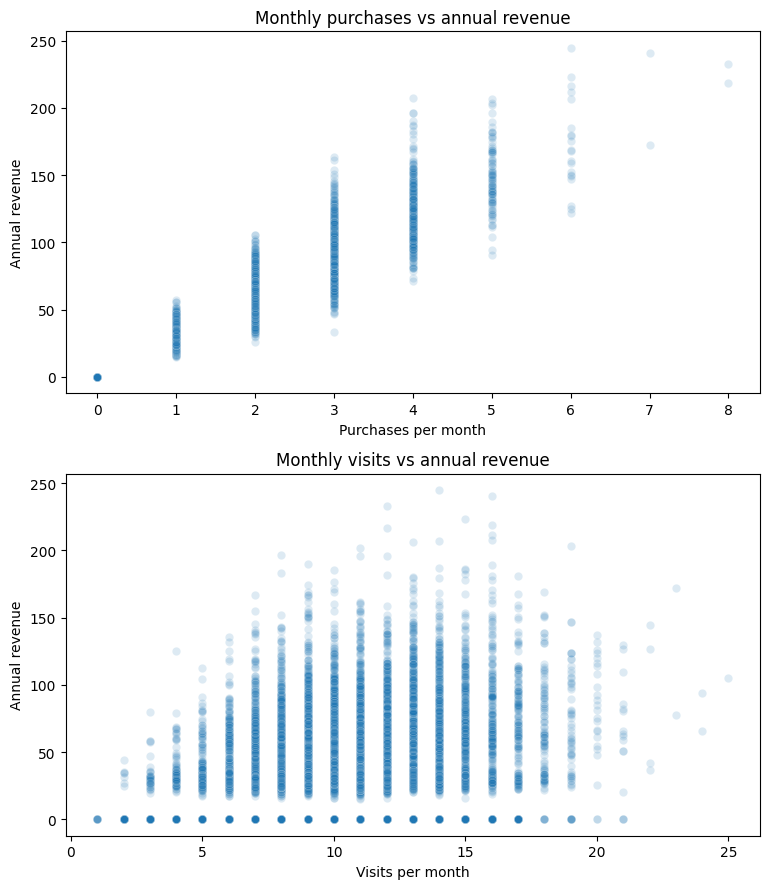

In [10]:
# Stacked rather than side by side: a figure wider than GitHub's notebook
# container forces a horizontal scrollbar that makes the whole page reflow
fig, axes = plt.subplots(2, 1, figsize=(7.8, 9))

# alpha is essential here: with 15,000 points a plain scatter becomes a solid
# block and the density of the cloud is impossible to read
sns.scatterplot(data=customer_behaviour, x='compras_mes', y='ingreso_anual',
                alpha=0.15, ax=axes[0])
axes[0].set_title('Monthly purchases vs annual revenue')
axes[0].set_xlabel('Purchases per month')
axes[0].set_ylabel('Annual revenue')

sns.scatterplot(data=customer_behaviour, x='visitas_mes', y='ingreso_anual',
                alpha=0.15, ax=axes[1])
axes[1].set_title('Monthly visits vs annual revenue')
axes[1].set_xlabel('Visits per month')
axes[1].set_ylabel('Annual revenue')

plt.tight_layout()
plt.show()

**What the scatterplots show**

**`compras_mes` vs `ingreso_anual`** — positive, tight and close to linear. The points stack into vertical bands because purchases are discrete, and each band sits higher than the last. The band at zero purchases sits flat on zero revenue, with no spread at all: nobody with zero purchases generated any revenue. That detail turns out to matter more than anything else in this analysis, and I come back to it in Section 5.

**`visitas_mes` vs `ingreso_anual`** — positive but much more diffuse. For any given number of visits, revenue ranges from zero to the top of the scale. Visits move with revenue, but weakly enough that visits alone tell you very little about what a customer will be worth.

## 4. How strong the relationships actually are

Numbers behind the patterns, one method per variable-type pairing.

### Pearson and Spearman

In [11]:
pairs = [('compras_mes', 'ingreso_anual'),
         ('visitas_mes', 'ingreso_anual')]

for a, b in pairs:
    pearson  = customer_behaviour[a].corr(customer_behaviour[b], method='pearson')
    spearman = customer_behaviour[a].corr(customer_behaviour[b], method='spearman')
    print(f'{a} vs {b}:  Pearson {pearson:.4f}  |  Spearman {spearman:.4f}')

compras_mes vs ingreso_anual:  Pearson 0.9671  |  Spearman 0.9675
visitas_mes vs ingreso_anual:  Pearson 0.3371  |  Spearman 0.3210


**Reading the coefficients**

**`compras_mes` vs `ingreso_anual` — 0.967 / 0.967.** Extremely strong and positive, and identical under both methods. Past the 0.85 threshold this stops being a finding about customer behaviour and becomes a warning about the data: the two columns carry nearly the same information.

**`visitas_mes` vs `ingreso_anual` — 0.337 / 0.321.** Moderate and positive. Pearson slightly above Spearman means a few high-visit, high-revenue customers pull the linear measure up; the rank-based measure is the more conservative read.

### Point-biserial

The right coefficient when one variable is a 0/1 flag and the other is continuous. Running Pearson here would return the same number, but naming the method correctly documents that the binary nature of the variable was considered rather than overlooked.

In [12]:
for flag in ['miembro_premium', 'abandono']:
    r, p = pointbiserialr(customer_behaviour[flag],
                          customer_behaviour['ingreso_anual'])
    print(f'{flag} vs ingreso_anual:  r = {r:.4f}  |  p = {p:.3g}')

miembro_premium vs ingreso_anual:  r = 0.0931  |  p = 3.09e-30
abandono vs ingreso_anual:  r = -0.0028  |  p = 0.729


**`miembro_premium` vs `ingreso_anual` — r = 0.093.** Positive but very weak. The p-value is tiny (3e-30), which with n = 15,000 says the association is real, not that it is large. Premium members do generate slightly more revenue, but the effect is too small to justify treating premium status as a revenue driver.

This is the clearest example in the analysis of why statistical significance and business relevance are different questions.

**`abandono` vs `ingreso_anual` — r = -0.003, p = 0.73.** Effectively zero, and not significant. Revenue tells you nothing about whether a customer churned: high-value customers leave at about the same rate as low-value ones. If the team wants to understand churn, revenue is the wrong place to look.

### Cramér's V

For associations between categorical variables. A binary flag is a categorical variable with two levels, so `abandono` and `miembro_premium` belong here as well as in the point-biserial section — measured against different things.

In [13]:
def cramers_v(var1, var2):
    """Cramér's V: chi-square normalised to a 0-1 scale."""
    table = pd.crosstab(customer_behaviour[var1], customer_behaviour[var2])
    chi2 = chi2_contingency(table)[0]
    n = table.sum().sum()
    min_dim = min(table.shape) - 1
    return np.sqrt(chi2 / (n * min_dim))

In [14]:
category_pairs = [('abandono', 'tipo_dispositivo'),
          ('abandono', 'region'),
          ('abandono', 'miembro_premium'),
          ('tipo_dispositivo', 'region')]

for a, b in category_pairs:
    print(f'{a:18s} vs {b:18s}  V = {cramers_v(a, b):.4f}')

abandono           vs tipo_dispositivo    V = 0.0072
abandono           vs region              V = 0.0154
abandono           vs miembro_premium     V = 0.1202
tipo_dispositivo   vs region              V = 0.0124


**Reading the four associations**

- **`abandono` vs `tipo_dispositivo` — 0.007.** No association. Churn does not depend on the device the customer uses.
- **`abandono` vs `region` — 0.015.** No association. Churn is not concentrated in any region.
- **`abandono` vs `miembro_premium` — 0.120.** The strongest of the four, though still weak. Premium status carries slightly more information about churn than geography or device do — the only lead in the churn direction this dataset offers.
- **`tipo_dispositivo` vs `region` — 0.012.** No association. Device preference is the same across all four regions, so device and region can be treated as independent dimensions in any segmentation.

Three of the four are effectively zero. Read together, they say something useful: churn in this dataset is not explained by who the customer is or where they are, which means the answer lies in behavioural variables this analysis has not covered.

## 5. What this means for the business

Five things came out of the analysis. The first two answer the question that was asked; the last three answer questions nobody asked but should have.

### Purchases and revenue are the same signal, not two

The scatterplot shows a tight, almost linear positive cloud, and the coefficients confirm it: **Pearson 0.967, Spearman 0.967** — identical under both methods, and the highest value in the matrix by a wide margin.

Past the 0.85 threshold this stops being a finding about customer behaviour and becomes a warning about the data. Monthly purchases and annual revenue are not two behaviours that happen to correlate; they are close to two measurements of the same thing. A customer's revenue is what their purchases added up to.

That means the number cannot be read as a lever. "Purchases drive revenue" is true in the same way that "distance drives mileage" is true — it describes an accounting identity, not an insight. What the business should take from it is narrower and more practical: **any model, dashboard or segmentation using both columns is double-counting.** Pick one. `ingreso_anual` is the one the business actually cares about.

### Visits move with revenue, but weakly

**Pearson 0.337, Spearman 0.321.** After purchases, visit frequency is the behaviour most associated with revenue — and the scatterplot shows why that association is thinner than the number suggests. At every visit count, revenue spans the full range from zero to the top of the scale. Plenty of frequent visitors generate nothing; some infrequent ones generate a lot.

Pearson sitting slightly above Spearman tells me a handful of high-visit, high-revenue customers are pulling the linear measure up. The rank-based figure is the more conservative read.

I cannot claim that driving visits produces revenue. The causality could run the other way — customers who already intend to buy visit more often — or both could follow from general interest in the category.

There is a tempting chain here: `gasto_publicidad_dirigida` correlates with `visitas_mes` at **0.58**, noticeably stronger than visits correlate with revenue. Ad spend to visits to revenue looks like a path, but it weakens at each step, and a chain of moderate correlations does not make a strong one. The only way to know whether it holds end to end is to test it: raise spend for a randomly assigned segment and measure the effect on visits **and** on revenue, not just on visits.

### A third of the customer base generates nothing

The descriptive statistics showed the 25th percentile of `ingreso_anual` sitting at zero. My first read was that this looked like a data quality problem worth flagging. It is not, and the check takes one line.

In [15]:
zero_revenue = customer_behaviour['ingreso_anual'] == 0
zero_purchases = customer_behaviour['compras_mes'] == 0

print(f'Customers with zero revenue  : {zero_revenue.sum():,} ({zero_revenue.mean():.1%})')
print(f'Customers with zero purchases: {zero_purchases.sum():,}')
print(f'Are they the same customers? {(zero_revenue == zero_purchases).all()}')

Customers with zero revenue  : 4,567 (30.4%)
Customers with zero purchases: 4,567
Are they the same customers? True


In [16]:
# How much of the 0.97 correlation comes from that block of paired zeros?
buyers = customer_behaviour[customer_behaviour['compras_mes'] > 0]

corr_with_non_buyers = customer_behaviour['compras_mes'].corr(customer_behaviour['ingreso_anual'])
corr_buyers_only = buyers['compras_mes'].corr(buyers['ingreso_anual'])

print(f'Pearson including non-buyers: {corr_with_non_buyers:.4f}')
print(f'Pearson among buyers only   : {corr_buyers_only:.4f}')

Pearson including non-buyers: 0.9671
Pearson among buyers only   : 0.9341


4,567 customers — **30.4% of the base** — generated zero revenue, and they are *exactly* the 4,567 who made zero purchases. The two sets match perfectly, which rules out missing data and recording errors. Revenue is zero because no purchase happened. Almost a third of the customer base used the platform during the period and bought nothing.

This also revises the first finding. Excluding non-buyers, the purchases-revenue correlation drops from **0.967 to 0.934** — still very high, but that block of paired zeros was inflating it.

**The pattern worth remembering:** a large, perfectly aligned zero segment sits as a dense cluster at the origin, and a correlation computed over it reports partly on the existence of that segment rather than on the relationship among everyone else. Whenever a coefficient comes back suspiciously high, check for zeros aligned across both variables and recompute without them.

The dataset records that these customers did not buy, not why. But the business implication stands on its own: the largest revenue opportunity here is not making buyers buy more. It is that thirty percent of the base buys nothing at all, and nobody was looking at them.

### Nothing in this dataset explains churn

I checked churn against everything available to it:

| Association with `abandono` | Coefficient | Reading |
|---|---|---|
| Annual revenue (point-biserial) | −0.003 (p = 0.73) | Nothing, and not significant |
| Device type (Cramér's V) | 0.007 | Nothing |
| Region (Cramér's V) | 0.015 | Nothing |
| Premium status (Cramér's V) | 0.120 | Weak, but the only lead |

High-value customers leave at about the same rate as low-value ones. Churn is not concentrated in any region or on any device.

A row of near-zero results is still a finding. It says the explanation lives in variables this dataset does not contain — support contacts, time since last purchase, in-session behaviour — and that any churn initiative built on revenue, geography or device would be built on nothing.

### Who the customer is tells you nothing; what they do tells you something

`edad`, `nivel_ingreso` and `satisfaccion` all sit near zero against revenue. Demographics do not separate valuable customers from the rest here — behaviour does.

One caveat I cannot resolve with this analysis: an aggregate near zero can hide opposing effects between subgroups. If older customers spent more and higher-income customers spent less, the two could cancel out and look like nothing. Ruling that out needs segmented analysis, which is on the list below.

### Premium status is real but too small to act on

**Point-biserial r = 0.093, p = 3e-30.** The p-value is minuscule, which with n = 15,000 means the association is real — not that it is large. Premium members do generate slightly more revenue, but the effect is small enough that treating premium status as a revenue driver would be a mistake.

This is the clearest example in the analysis of why statistical significance and business relevance are separate questions. With a sample this size, almost anything reaches significance. The size of the effect is what decides whether it matters.

## 6. What this analysis cannot answer

### Limitations

**Correlation is not causation.** Every relationship here is an association measured in 2024 data. None of them establishes that changing one variable would move another.

**This is exploratory, not predictive.** It maps relationships that exist in the data. It does not build or validate a model that forecasts what a customer will be worth.

**`compras_mes` and `ingreso_anual` are collinear.** At 0.967 they carry nearly identical information, and treating them as independent signals would be a methodological error rather than a judgement call.

**The zero-revenue segment shapes every coefficient.** 30.4% of customers generated nothing, and that block affects anything computed over the full base — demonstrated above for the strongest pair, but true of all of them.

**Subgroup effects were not ruled out.** Customer attributes sit near zero in aggregate, and an aggregate near zero can mask opposing effects that cancel.

### What I would do next

1. **Analyse the non-buyers on their own.** Compare the 4,567 against buyers on visits, ad spend, satisfaction and device. Converting a fraction of a third of the base is worth more than optimising the customers already buying, and this analysis says nothing about why they do not convert.

2. **Test the advertising chain with an experiment.** Ad spend correlates with visits at 0.58 and visits with revenue at 0.34. Only a randomised test can tell whether the chain holds end to end, and it has to measure revenue, not just visits — otherwise it confirms the strong link and assumes the weak one.

3. **Look for churn drivers outside this dataset.** Revenue, device and region say nothing; premium status is a weak lead. The answer needs data that is not here.

4. **Re-run the correlations within segments.** Separately for buyers, for premium members, and by region — to see whether the aggregate coefficients hold or whether they are averaging out patterns that point in opposite directions.